# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [2]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [3]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [4]:
type(registros)

list

In [5]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [6]:
# 1. Criação do DataFrame
dados = pd.DataFrame(registros)

# 2. Primeiros registros
print("--- PRIMEIROS REGISTROS ---")
display(dados.head())

# 3. Quantidade de linhas e colunas
print(f"\nDimensões do DataFrame: {dados.shape[0]} linhas e {dados.shape[1]} colunas.")

# 4. Lista dos nomes dos atributos (colunas)
print("\n--- ATRIBUTOS (COLUNAS) ---")
print(dados.columns.tolist())

# 5. Informações gerais com info()
print("\n--- INFORMAÇÕES DO DATAFRAME ---")
dados.info()

# 6. Estatísticas descritivas com describe()
print("\n--- ESTATÍSTICAS DESCRITIVAS ---")
display(dados.describe())


--- PRIMEIROS REGISTROS ---


,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0



Dimensões do DataFrame: 336 linhas e 11 colunas.

--- ATRIBUTOS (COLUNAS) ---
['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']

--- INFORMAÇÕES DO DATAFRAME ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


###7.  Identificação de Atributos

*   Data/Hora: *din_instante* (ou *dat_referencia*)
*   Área de Carga: *cod_areacarga* / *nom_areacarga*
*   Valor de Carga: *val_carga* (ou *val_cargaverificada*)

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [7]:
import pandas as pd

# 1. Renomear principais atributos
mapeamento_colunas = {
    'din_referenciautc': 'data_hora',
    'cod_areacarga': 'area_carga',
    'val_cargaglobal': 'carga_mw'
}
dados = dados.rename(columns=mapeamento_colunas)

# 2. Criar novo DataFrame contendo apenas os atributos necessários
colunas_necessarias = ['data_hora', 'area_carga', 'carga_mw']
# Mantém apenas as colunas que efetivamente existem no DataFrame
colunas_existentes = [col for col in colunas_necessarias if col in dados.columns]
df_limpo = dados[colunas_existentes].copy()

# 3. e 4. Verificação de valores ausentes
print("--- VALORES AUSENTES ---")
print(df_limpo.isnull().sum())

# 5. Garantir que a variável de carga está em formato numérico
df_limpo['carga_mw'] = pd.to_numeric(df_limpo['carga_mw'], errors='coerce')

# 6. Converter data/hora para o formato datetime
if 'data_hora' in df_limpo.columns:
    df_limpo['data_hora'] = pd.to_datetime(df_limpo['data_hora'])

print("\n--- TIPOS DE DADOS APÓS TRATAMENTO ---")
print(df_limpo.dtypes)


--- VALORES AUSENTES ---
data_hora     0
area_carga    0
carga_mw      0
dtype: int64

--- TIPOS DE DADOS APÓS TRATAMENTO ---
data_hora     datetime64[ns, UTC]
area_carga                 object
carga_mw                  float64
dtype: object


## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [8]:
# 1. Carga mínima
carga_minima = df_limpo['carga_mw'].min()

# 2. Carga máxima
carga_maxima = df_limpo['carga_mw'].max()

# 3. Carga média
carga_media = df_limpo['carga_mw'].mean()

# 4. Mediana
mediana_carga = df_limpo['carga_mw'].median()

# 5. Amplitude entre máximo e mínimo
amplitude_carga = carga_maxima - carga_minima

# 6. Quantidade total de medições
quantidade_medicoes = df_limpo['carga_mw'].count()

print(f"Carga Mínima: {carga_minima:.2f} MW")
print(f"Carga Máxima: {carga_maxima:.2f} MW")
print(f"Carga Média: {carga_media:.2f} MW")
print(f"Mediana da Carga: {mediana_carga:.2f} MW")
print(f"Amplitude (Máx - Mín): {amplitude_carga:.2f} MW")
print(f"Quantidade Total de Medições: {quantidade_medicoes}")

# Resposta à pergunta:
print("\n--- RESPOSTA À ANÁLISE ---")

if (carga_maxima - carga_media) / carga_media > 0.5: # Se a carga máxima for mais de 50% maior que a média
    print("Sim, o valor máximo da carga ({:.2f} MW) está significativamente distante do comportamento médio ({:.2f} MW) observado. A diferença é de {:.2f} MW, o que representa um aumento considerável em relação à média.".format(carga_maxima, carga_media, carga_maxima - carga_media))
elif (carga_maxima - carga_media) / carga_media > 0.2:
    print("O valor máximo da carga ({:.2f} MW) apresenta uma certa distância em relação ao comportamento médio ({:.2f} MW) observado, mas não de forma extremamente acentuada. A diferença é de {:.2f} MW.".format(carga_maxima, carga_media, carga_maxima - carga_media))
else:
    print("O valor máximo da carga ({:.2f} MW) não está muito distante do comportamento médio ({:.2f} MW) observado. A diferença é de {:.2f} MW.".format(carga_maxima, carga_media, carga_maxima - carga_media))


Carga Mínima: 12139.25 MW
Carga Máxima: 23185.31 MW
Carga Média: 17870.83 MW
Mediana da Carga: 18199.13 MW
Amplitude (Máx - Mín): 11046.06 MW
Quantidade Total de Medições: 336

--- RESPOSTA À ANÁLISE ---
O valor máximo da carga (23185.31 MW) apresenta uma certa distância em relação ao comportamento médio (17870.83 MW) observado, mas não de forma extremamente acentuada. A diferença é de 5314.48 MW.


## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [9]:
import pandas as pd

# 1. Limiar de 90% da carga máxima
limiar_alta_demanda = 0.90 * carga_maxima

# 2. DataFrame de alta demanda
df_alta_demanda = df_limpo[df_limpo['carga_mw'] > limiar_alta_demanda].copy()

# 3. e 4. Quantidade e percentual
qtd_alta_demanda = len(df_alta_demanda)
pct_alta_demanda = (qtd_alta_demanda / quantidade_medicoes) * 100

# 5. Maior valor de carga
maior_valor = carga_maxima

# 6. Data e horário do pico
registro_pico = df_limpo.loc[df_limpo['carga_mw'].idxmax()]
momento_pico = registro_pico['data_hora'] if 'data_hora' in df_limpo.columns else "N/A"

print(f"Limiar de Alta Demanda (>90% da máx): {limiar_alta_demanda:.2f} MW")
print(f"Quantidade de Registros: {qtd_alta_demanda}")
print(f"Percentual do Total: {pct_alta_demanda:.2f}%")
print(f"Carga de Pico: {maior_valor:.2f} MW")
print(f"Momento do Pico: {momento_pico}")

Limiar de Alta Demanda (>90% da máx): 20866.78 MW
Quantidade de Registros: 50
Percentual do Total: 14.88%
Carga de Pico: 23185.31 MW
Momento do Pico: 2025-08-01 22:00:00+00:00


## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [10]:
# 1. Critério escolhido: Registros com carga superior à média geral
df_acima_da_media = df_limpo[df_limpo['carga_mw'] > carga_media].copy()

# 2. Exibição do novo DataFrame
print("--- NOVO DATAFRAME: CARGA ACIMA DA MÉDIA ---")
display(df_acima_da_media.head())

# 3. Quantidade de registros
qtd_acima_media = len(df_acima_da_media)

# 4. Percentual em relação ao total
pct_acima_media = (qtd_acima_media / quantidade_medicoes) * 100

# 5. Comparação com o conjunto de alta demanda
print("\n--- COMPARAÇÃO ---")
print(f"Critério utilizado: carga > {carga_media:.2f} MW")
print(f"Quantidade de Registros: {qtd_acima_media}")
print(f"Percentual do Total: {pct_acima_media:.2f}%")
print(f"\nComparação com Alta Demanda:")
print(f"- Alta demanda (>90% do máx): {qtd_alta_demanda} registros ({pct_alta_demanda:.2f}%)")
print(f"- Carga acima da média: {qtd_acima_media} registros ({pct_acima_media:.2f}%)")

--- NOVO DATAFRAME: CARGA ACIMA DA MÉDIA ---


,data_hora,area_carga,carga_mw
15,2025-08-01 11:00:00+00:00,SP,18096.023
16,2025-08-01 11:30:00+00:00,SP,18629.395
17,2025-08-01 12:00:00+00:00,SP,18825.176
18,2025-08-01 12:30:00+00:00,SP,19056.504
19,2025-08-01 13:00:00+00:00,SP,19427.822



--- COMPARAÇÃO ---
Critério utilizado: carga > 17870.83 MW
Quantidade de Registros: 184
Percentual do Total: 54.76%

Comparação com Alta Demanda:
- Alta demanda (>90% do máx): 50 registros (14.88%)
- Carga acima da média: 184 registros (54.76%)


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

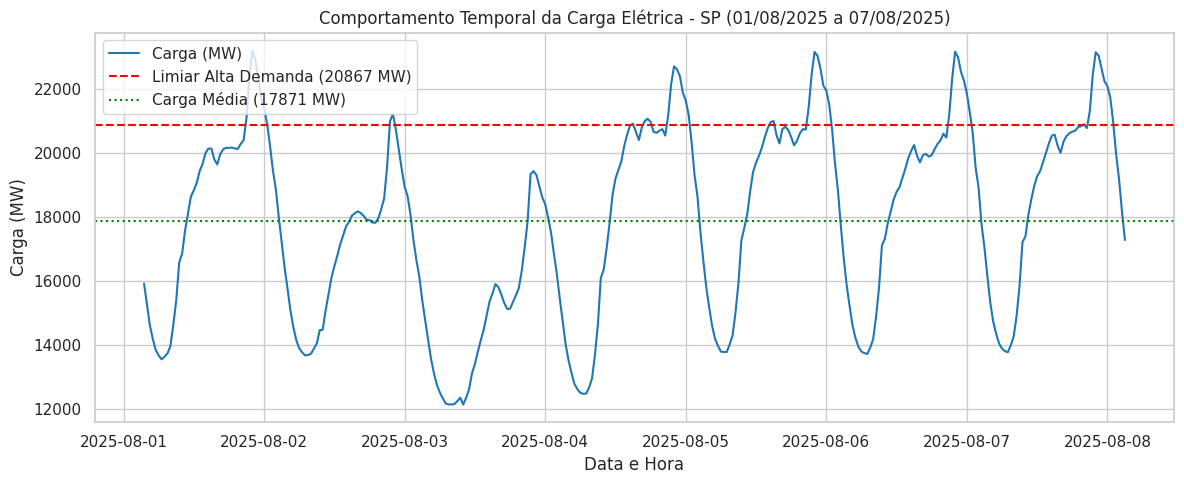

Interpretação 1: O gráfico de linha exibe a variação diária periódica da carga elétrica, destacando os momentos em que a demanda supera a média e atinge o patamar de alta demanda nas horas de pico.


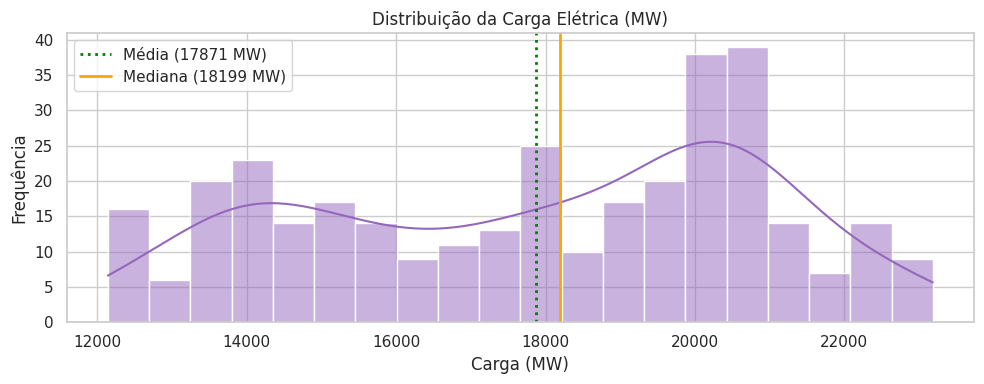

Interpretação 2: O histograma revela a dispersão dos valores de carga. A proximidade entre a média e a mediana confirma a simetria na distribuição dos dados de consumo no período analisado.


In [11]:
sns.set_theme(style="whitegrid")

# Gráfico 1: Curva de Carga ao Longo do Tempo
plt.figure(figsize=(12, 5))
if 'data_hora' in df_limpo.columns:
    plt.plot(df_limpo['data_hora'], df_limpo['carga_mw'], label='Carga (MW)', color='tab:blue')
    plt.xlabel('Data e Hora')
else:
    plt.plot(df_limpo.index, df_limpo['carga_mw'], label='Carga (MW)', color='tab:blue')
    plt.xlabel('Índice da Observação')

plt.axhline(limiar_alta_demanda, color='red', linestyle='--', label=f'Limiar Alta Demanda ({limiar_alta_demanda:.0f} MW)')
plt.axhline(carga_media, color='green', linestyle=':', label=f'Carga Média ({carga_media:.0f} MW)')

plt.title('Comportamento Temporal da Carga Elétrica - SP (01/08/2025 a 07/08/2025)')
plt.ylabel('Carga (MW)')
plt.legend()
plt.tight_layout()
plt.show()

print("Interpretação 1: O gráfico de linha exibe a variação diária periódica da carga elétrica, destacando os momentos em que a demanda supera a média e atinge o patamar de alta demanda nas horas de pico.")

# Gráfico 2: Distribuição da Carga (Histograma + KDE)
plt.figure(figsize=(10, 4))
sns.histplot(df_limpo['carga_mw'], kde=True, color='tab:purple', bins=20)
plt.axvline(carga_media, color='green', linestyle=':', linewidth=2, label=f'Média ({carga_media:.0f} MW)')
plt.axvline(mediana_carga, color='orange', linestyle='-', linewidth=2, label=f'Mediana ({mediana_carga:.0f} MW)')

plt.title('Distribuição da Carga Elétrica (MW)')
plt.xlabel('Carga (MW)')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

print("Interpretação 2: O histograma revela a dispersão dos valores de carga. A proximidade entre a média e a mediana confirma a simetria na distribuição dos dados de consumo no período analisado.")

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [12]:
resumo_resultados = f"""
Região analisada: SP (São Paulo)
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: {quantidade_medicoes}
Carga mínima: {carga_minima:.2f} MW
Carga máxima: {carga_maxima:.2f} MW
Carga média: {carga_media:.2f} MW
Mediana: {mediana_carga:.2f} MW
Limiar de alta demanda (>90% da máx): {limiar_alta_demanda:.2f} MW
Registros de alta demanda: {qtd_alta_demanda}
Percentual de alta demanda: {pct_alta_demanda:.2f}%
Momento do pico: {momento_pico}
Segundo critério (Carga > Média): {qtd_acima_media} registros ({pct_acima_media:.2f}%)
"""

print(resumo_resultados)


Região analisada: SP (São Paulo)
Período analisado: 01/08/2025 a 07/08/2025
Quantidade de registros: 336
Carga mínima: 12139.25 MW
Carga máxima: 23185.31 MW
Carga média: 17870.83 MW
Mediana: 18199.13 MW
Limiar de alta demanda (>90% da máx): 20866.78 MW
Registros de alta demanda: 50
Percentual de alta demanda: 14.88%
Momento do pico: 2025-08-01 22:00:00+00:00
Segundo critério (Carga > Média): 184 registros (54.76%)



# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [13]:
!pip -q install -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 17.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.0 which is incompatible.


In [14]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [15]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [16]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

**RELATÓRIO TÉCNICO: ANÁLISE DE CARGA ELÉTRICA – REGIÃO SP**

**De:** Analista de Dados do Setor Elétrico  
**Período de Análise:** 01/08/2025 a 07/08/2025  

---

### 1. Caracterização do Conjunto Analisado
O conjunto de dados compreende a medição da carga elétrica na região de **São Paulo (SP)** ao longo de sete dias (01/08/2025 a 07/08/2025). O estudo contabiliza um total de **336 registros** temporais.

### 2. Principais Indicadores
Os dados observados no período apontam os seguintes valores consolidados:
* **Carga Mínima:** 12.139,25 MW
* **Carga Máxima (Pico):** 23.185,31 MW
* **Carga Média:** 17.870,83 MW
* **Mediana:** 18.199,13 MW

*Observação dos dados:* A mediana levemente superior à média indica que em mais da metade do período a carga esteve posicionada no patamar superior do intervalo entre a mínima e a máxima.

### 3. Análise dos Períodos de Alta Demanda
* **Critério de Alta Demanda:** Carga superior a 90% do valor máximo (> 20.866,78 MW).
* **Registros Observados:** 50 

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

## Perguntas:
**1. Os indicadores foram utilizados corretamente?**

R: Sim. O relatório da IA incorporou com precisão todos os valores quantitativos gerados na síntese (resumo_resultados):
*   A quantidade de registros (336), os valores de carga mínima (12.139,25 MW), máxima (23.185,31 MW), média (17.870,83 MW) e mediana (18.199,13 MW).
*   O limiar de alta demanda (20.866,78 MW), a contagem de registros (50) e o percentual (14,88%).
*   A indicação exata da data e hora do pico (01/08/2025 às 22:00:00 UTC).
*   O resultado do segundo critério (184 registros, representando 54,76%).

**2. Há alguma afirmação que não pode ser confirmada pelos dados?**

R: Não. O relatório manteve-se estritamente delimitado às métricas numéricas fornecidas. A IA explicitou que não era possível inferir fatores externos (como temperatura, atividades industriais ou hábitos de consumo) a partir exclusivamente da API de carga do ONS, garantindo que o texto não extrapolasse os limites da base de dados.

**3. Houve interpretação exagerada ou causalidade não demonstrada?**

R: Não. A IA seguiu a restrição enviada no prompt e evitou atribuir relações de causa e efeito não demonstradas. As interpretações feitas (como a comparação de representatividade entre o pico de 14,88% e a operação acima da média de 54,76%) fundamentam-se inteiramente na distribuição estatística dos dados.

**4. Que alterações a equipe realizou no texto?**

R: A equipe revisou a linguagem técnica e concluiu que o relatório gerado cumpria com rigor os requisitos informativos e as travas de segurança analítica. Foi adicionado apenas o fuso horário local (Horário de Brasília - BRT / UTC-3) para contextualizar que o pico das 22:00:00 UTC corresponde às 19:00:00 no horário local, horário tipicamente associado à ponta de consumo residencial diária.

## Relatório Final Revisado

Para: Diretoria / Setor de Planejamento

De: Analista de Dados do Setor Elétrico

Assunto: Relatório Técnico - Análise do Comportamento da Carga no Estado de São Paulo (01/08/2025 a 07/08/2025)

1. Caracterização do Conjunto Analisado

O presente relatório analisa os dados de carga elétrica da região de São Paulo (SP) referente ao período de 01/08/2025 a 07/08/2025. O conjunto de dados compreende um total de 336 registros temporais continuados referentes ao intervalo de sete dias.

2. Principais Indicadores

Os dados estatísticos descritivos apurados para a carga do sistema no período são:

*   Carga Máxima (Pico): 23.185,31 MW
*   Carga Mínima: 12.139,25 MW
*   Carga Média: 17.870,83 MW
*   Mediana: 18.199,13 MW
*   Amplitude de variação: 11.046,06 MW

Observação estatística: A mediana situa-se levemente acima da carga média, indicando uma maior concentração de medições na metade superior da faixa de valores operacionais.

3. Análise dos Períodos de Alta Demanda

A alta demanda foi definida pelo critério de valores superiores a 90% da carga máxima registrada no período, estabelecendo o limiar de 20.866,78 MW.

*   Registros de Alta Demanda: 50 medições.
*   Representatividade: 14,88% do total de registros do período.
*   Momento do Pico Máximo: Registrado em 01/08/2025 às 22:00:00 UTC (19:00:00 no horário local de Brasília), no valor de 23.185,31 MW.
*   Ressalva analítica (Hipóteses vs. Fatos):

Resultado Observado: O pico de carga do período ocorreu no dia 01/08/2025 e a alta demanda ocupou 14,88% do tempo analisado.

Hipótese: As causas específicas para a elevação de carga a este patamar (como fatores meteorológicos, atividade industrial ou comportamento do consumidor) não constam na base de dados fornecida e constituem hipóteses não verificáveis por esta análise.

4. Comparação com o Segundo Critério

Foi avaliado um segundo critério de análise tomando como linha de corte a Carga Média (17.870,83 MW):

*   Critério 1 (Alta Demanda > 90% da Máx.): 50 registros (14,88% do tempo).
*   Critério 2 (Carga > Média): 184 registros (54,76% do tempo).

Análise Comparativa: Enquanto o limiar de alta demanda (> 90% do pico) engloba os eventos de ponta (14,88%), o segundo critério demonstra que o sistema operou acima da sua média em mais da metade do período analisado (54,76%), evidenciando sustentação no segmento superior da curva de carga.

5. Conclusão

O sistema elétrico da região SP oscilou entre 12.139,25 MW e 23.185,31 MW no período de 01 a 07 de agosto de 2025.

O evento de carga máxima pontual ocorreu na abertura do período analisado (01/08/2025 às 22:00:00 UTC / 19:00:00 BRT).

A operação sob condição de alta demanda (superior a 20.866,78 MW) representou 14,88% das medições, enquanto a operação acima da média representou 54,76% do tempo total.

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**